# EduLink — Model 1: Career Fit Prediction
**Industry-Level | PySpark ML | Multi-Algorithm | Hyperparameter Tuning | Full Validation**

**Pipeline:**
1. Mount Drive & Start Spark
2. Load & Prepare Dataset
3. Label Generation (Theory-based scoring)
4. Train/Test Split
5. Train Multiple Algorithms: Decision Tree, Random Forest, GBT, Logistic Regression
6. Hyperparameter Tuning with CrossValidator + ParamGridBuilder
7. Full Evaluation: Accuracy, F1, Precision, Recall, Confusion Matrix
8. Save Best Model
9. Generate Career Report (Top1/Top2/Top3 clusters + 10 job roles)

In [1]:
# ─── CELL 1: Setup ───
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!pip install -q pyspark
print("Setup complete.")


Mounted at /content/drive
Setup complete.


In [2]:
# ─── CELL 2: Spark Session ───
from pyspark.sql import SparkSession

spark = (SparkSession.builder
         .appName("EDUCLINE-CareerFit-v2")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)


Spark version: 4.0.2


In [3]:
# ─── CELL 3: Paths ───
import os

ROOT  = "/content/drive/MyDrive/FYP1"
DATA  = f"{ROOT}/Dataset"        # all CSVs here
MODEL = f"{ROOT}/Model"          # trained models here
TEST  = f"{ROOT}/Test and Validation"  # validation reports here

DATA_PATH      = f"{DATA}/synthetic_exam_master_2000.csv"
LABELED_PATH   = f"{DATA}/career_fit_labeled.parquet"
MODEL_OUT      = f"{MODEL}/career_fit_best_model"
REPORT_OUT_DIR = f"{TEST}/career_fit_report_csv"
FINAL_CSV      = f"{DATA}/career_fit_report.csv"

# Auto-create folders if they don't exist
for folder_path in [DATA, MODEL, TEST]:
    os.makedirs(folder_path, exist_ok=True)

print("EXISTS:", os.path.exists(DATA_PATH), "->", DATA_PATH)


EXISTS: True -> /content/drive/MyDrive/FYP1/Dataset/synthetic_exam_master_2000.csv


In [4]:
# ─── CELL 4: Load Dataset ───
from pyspark.sql import functions as F

df_raw = (spark.read
          .option("header", True)
          .option("inferSchema", True)
          .csv(DATA_PATH))

print(f"Rows: {df_raw.count()} | Columns: {len(df_raw.columns)}")
df_raw.printSchema()
df_raw.show(3, truncate=False)


Rows: 2000 | Columns: 69
root
 |-- student_id: integer (nullable = true)
 |-- persona: string (nullable = true)
 |-- Q1: integer (nullable = true)
 |-- Q2: integer (nullable = true)
 |-- Q3: integer (nullable = true)
 |-- Q4: integer (nullable = true)
 |-- Q5: integer (nullable = true)
 |-- Q6: integer (nullable = true)
 |-- Q7: integer (nullable = true)
 |-- Q8: integer (nullable = true)
 |-- Q9: integer (nullable = true)
 |-- Q10: integer (nullable = true)
 |-- Q11: integer (nullable = true)
 |-- Q12: integer (nullable = true)
 |-- Q13: integer (nullable = true)
 |-- Q14: integer (nullable = true)
 |-- Q15: integer (nullable = true)
 |-- Q16: integer (nullable = true)
 |-- Q17: integer (nullable = true)
 |-- Q18: integer (nullable = true)
 |-- Q19: integer (nullable = true)
 |-- Q20: integer (nullable = true)
 |-- Q21: integer (nullable = true)
 |-- Q22: integer (nullable = true)
 |-- Q23: integer (nullable = true)
 |-- Q24: integer (nullable = true)
 |-- Q25: integer (nullable = tru

In [5]:
# ─── CELL 5: Theory-Based Label Generation ───
# Based on Holland RIASEC + Trait-Factor Theory + SCCT
# Weighted scoring maps MCQ features -> career cluster

A  = F.col("Analytical_Thinking")
CR = F.col("Creativity_Index")
L  = F.col("Leadership_Capability")
DL = F.col("Data_Literacy")
TA = F.col("Tech_Adaptability")
TP = F.col("Technical_ProblemSolving")
SI = F.col("Social_Intelligence")
CS = F.col("Communication_Skill")
BE = F.col("Business_Economics_Interest")
EO = F.col("Entrepreneurship_Orientation")
PO = F.col("Process_Optimization")
SP = F.col("Structure_Preference")
TI = F.col("Tech_Interest")

SCORE_COLS = [
    "score_Data_AI_Engineering",
    "score_Software_Web_Engineering",
    "score_Network_Infrastructure",
    "score_IT_Operations_QA",
    "score_UX_Creative_Tech",
    "score_Business_IT_Management",
    "score_Digital_Marketing_Media",
    "score_Hardware_Systems",
]

df_scored = (df_raw
    .withColumn("score_Data_AI_Engineering",      1.25*A + 1.25*DL + 0.90*TI + 0.35*TA + 0.25*SP)
    .withColumn("score_Software_Web_Engineering", 1.15*TA + 1.05*TP + 0.75*A  + 0.65*TI + 0.25*PO)
    .withColumn("score_Network_Infrastructure",   1.20*TP + 1.10*PO + 1.00*SP + 0.55*TA + 0.20*A)
    .withColumn("score_IT_Operations_QA",         1.20*SP + 1.05*PO + 0.85*A  + 0.65*TA + 0.25*CS)
    .withColumn("score_UX_Creative_Tech",         1.35*CR + 0.75*SI + 0.90*CS + 0.55*TI + 0.25*TA)
    .withColumn("score_Business_IT_Management",   1.25*L  + 1.05*BE + 0.85*CS + 0.60*SI + 0.25*A)
    .withColumn("score_Digital_Marketing_Media",  1.25*CS + 1.05*SI + 0.95*EO + 0.80*CR + 0.45*BE)
    .withColumn("score_Hardware_Systems",         1.25*TP + 0.85*A  + 0.80*TA + 0.60*PO + 0.45*DL)
)

df_labeled = (df_scored
    .withColumn("best_score", F.greatest(*SCORE_COLS))
    .withColumn("career_cluster",
        F.when(F.col("best_score") == F.col("score_Data_AI_Engineering"),      "Data_AI_Engineering")
         .when(F.col("best_score") == F.col("score_Software_Web_Engineering"), "Software_Web_Engineering")
         .when(F.col("best_score") == F.col("score_Network_Infrastructure"),   "Network_Infrastructure")
         .when(F.col("best_score") == F.col("score_IT_Operations_QA"),         "IT_Operations_QA")
         .when(F.col("best_score") == F.col("score_UX_Creative_Tech"),         "UX_Creative_Tech")
         .when(F.col("best_score") == F.col("score_Business_IT_Management"),   "Business_IT_Management")
         .when(F.col("best_score") == F.col("score_Digital_Marketing_Media"),  "Digital_Marketing_Media")
         .otherwise("Hardware_Systems")
    )
)

print("Class distribution:")
df_labeled.groupBy("career_cluster").count().orderBy(F.desc("count")).show()

# Save labeled parquet
df_labeled.write.mode("overwrite").parquet(LABELED_PATH)
print("Saved labeled parquet:", LABELED_PATH)


Class distribution:
+--------------------+-----+
|      career_cluster|count|
+--------------------+-----+
|Digital_Marketing...|  987|
| Data_AI_Engineering|  380|
|Network_Infrastru...|  281|
|    IT_Operations_QA|  187|
|    Hardware_Systems|   91|
|Software_Web_Engi...|   51|
|Business_IT_Manag...|   21|
|    UX_Creative_Tech|    2|
+--------------------+-----+

Saved labeled parquet: /content/drive/MyDrive/FYP1/Dataset/career_fit_labeled.parquet


In [6]:
# ─── CELL 6: Feature Engineering & Train/Test Split ───
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler
from pyspark.ml import Pipeline

FEATURES = [
    "Analytical_Thinking", "Structure_Preference", "Creativity_Index",
    "Emotional_Stability", "Strategic_Vision", "Innovation_Drive",
    "Social_Intelligence", "Data_Literacy", "Tech_Adaptability",
    "Communication_Skill", "Technical_ProblemSolving", "Leadership_Capability",
    "Process_Optimization", "Tech_Interest", "Business_Economics_Interest",
    "Social_Impact_Motivation", "Future_Orientation", "Career_Growth_Mindset",
    "Entrepreneurship_Orientation", "Global_Innovation_Alignment",
    "R", "I", "A", "S", "E", "C"
]

df_ml = spark.read.parquet(LABELED_PATH)

# 80/20 stratified-like split (seed fixed for reproducibility)
train_df, test_df = df_ml.randomSplit([0.80, 0.20], seed=42)
train_df.cache()
test_df.cache()

print(f"Train: {train_df.count()} | Test: {test_df.count()}")


Train: 1642 | Test: 358


In [7]:
# ─── CELL 7: Train Multiple Algorithms + Compare ───
from pyspark.ml.classification import (
    DecisionTreeClassifier,
    RandomForestClassifier,
    LogisticRegression,
    OneVsRest,
    LinearSVC,
)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

label_indexer = StringIndexer(inputCol="career_cluster", outputCol="label", handleInvalid="keep")
assembler     = VectorAssembler(inputCols=FEATURES, outputCol="raw_features", handleInvalid="skip")
scaler        = StandardScaler(inputCol="raw_features", outputCol="features", withMean=True, withStd=True)

# OneVsRest wraps LinearSVC to support 8 classes (SVC alone only handles 2 classes)
ovr_svc = OneVsRest(
    classifier=LinearSVC(labelCol="label", featuresCol="features", maxIter=100, regParam=0.01),
    labelCol="label",
    featuresCol="features"
)

ALGORITHMS = {
    "DecisionTree":  DecisionTreeClassifier(labelCol="label", featuresCol="features",
                                            maxDepth=6, minInstancesPerNode=10, seed=42),
    "RandomForest":  RandomForestClassifier(labelCol="label", featuresCol="features",
                                            numTrees=100, maxDepth=8, seed=42),
    "OvR_LinearSVC": ovr_svc,
    "LogisticReg":   LogisticRegression(labelCol="label", featuresCol="features",
                                        maxIter=200, regParam=0.01, family="multinomial"),
}

acc_eval  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
f1_eval   = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
prec_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
rec_eval  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

results       = {}
fitted_models = {}

print(f"{'Algorithm':<20} {'Accuracy':>10} {'F1':>10} {'Precision':>10} {'Recall':>10}")
print("-" * 65)

for name, clf in ALGORITHMS.items():
    stages = [label_indexer, assembler, scaler, clf]
    pipe   = Pipeline(stages=stages)
    model  = pipe.fit(train_df)
    preds  = model.transform(test_df)

    acc  = float(acc_eval.evaluate(preds))
    f1   = float(f1_eval.evaluate(preds))
    prec = float(prec_eval.evaluate(preds))
    rec  = float(rec_eval.evaluate(preds))

    results[name]       = {"accuracy": acc, "f1": f1, "precision": prec, "recall": rec}
    fitted_models[name] = model

    print(f"{name:<20} {acc:>10.4f} {f1:>10.4f} {prec:>10.4f} {rec:>10.4f}")

best_name = max(results, key=lambda k: results[k]["f1"])
print(f"\n>>> BEST MODEL: {best_name} | F1={results[best_name]['f1']:.4f} | Accuracy={results[best_name]['accuracy']:.4f}")

Algorithm              Accuracy         F1  Precision     Recall
-----------------------------------------------------------------
DecisionTree             0.6341     0.6216     0.6211     0.6341
RandomForest             0.7542     0.7307     0.7620     0.7542
OvR_LinearSVC            0.8575     0.8399     0.8608     0.8575
LogisticReg              0.9190     0.9124     0.9142     0.9190

>>> BEST MODEL: LogisticReg | F1=0.9124 | Accuracy=0.9190


In [8]:
# ─── CELL 8: Hyperparameter Tuning on Best Model ───
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

print(f"Tuning: {best_name}")

if best_name == "RandomForest":
    clf_tune = RandomForestClassifier(labelCol="label", featuresCol="features", seed=42)
    param_grid = (ParamGridBuilder()
        .addGrid(clf_tune.numTrees, [50, 100, 150])
        .addGrid(clf_tune.maxDepth, [6, 8, 10])
        .addGrid(clf_tune.minInstancesPerNode, [5, 10])
        .build())
    tune_pipeline = Pipeline(stages=[label_indexer, assembler, scaler, clf_tune])

elif best_name == "DecisionTree":
    clf_tune = DecisionTreeClassifier(labelCol="label", featuresCol="features", seed=42)
    param_grid = (ParamGridBuilder()
        .addGrid(clf_tune.maxDepth, [4, 6, 8, 10])
        .addGrid(clf_tune.minInstancesPerNode, [5, 10, 15])
        .build())
    tune_pipeline = Pipeline(stages=[label_indexer, assembler, scaler, clf_tune])

elif best_name == "OvR_LinearSVC":
    base_svc  = LinearSVC(labelCol="label", featuresCol="features")
    clf_tune  = OneVsRest(classifier=base_svc, labelCol="label", featuresCol="features")
    param_grid = (ParamGridBuilder()
        .addGrid(base_svc.maxIter,  [50, 100, 150])
        .addGrid(base_svc.regParam, [0.001, 0.01, 0.1])
        .build())
    tune_pipeline = Pipeline(stages=[label_indexer, assembler, scaler, clf_tune])

else:  # LogisticReg
    clf_tune = LogisticRegression(labelCol="label", featuresCol="features", family="multinomial")
    param_grid = (ParamGridBuilder()
        .addGrid(clf_tune.regParam,  [0.001, 0.01, 0.1])
        .addGrid(clf_tune.maxIter,   [100, 200, 300])
        .build())
    tune_pipeline = Pipeline(stages=[label_indexer, assembler, scaler, clf_tune])

cv = CrossValidator(
    estimator=tune_pipeline,
    estimatorParamMaps=param_grid,
    evaluator=f1_eval,
    numFolds=5,
    seed=42,
    parallelism=2,
)

cv_model    = cv.fit(train_df)
tuned_preds = cv_model.transform(test_df)

tuned_acc  = float(acc_eval.evaluate(tuned_preds))
tuned_f1   = float(f1_eval.evaluate(tuned_preds))
tuned_prec = float(prec_eval.evaluate(tuned_preds))
tuned_rec  = float(rec_eval.evaluate(tuned_preds))

print(f"\n{'Metric':<15} {'Before Tuning':>15} {'After Tuning':>15}")
print("-" * 50)
print(f"{'Accuracy':<15} {results[best_name]['accuracy']:>15.4f} {tuned_acc:>15.4f}")
print(f"{'F1':<15} {results[best_name]['f1']:>15.4f} {tuned_f1:>15.4f}")
print(f"{'Precision':<15} {results[best_name]['precision']:>15.4f} {tuned_prec:>15.4f}")
print(f"{'Recall':<15} {results[best_name]['recall']:>15.4f} {tuned_rec:>15.4f}")

Tuning: LogisticReg

Metric            Before Tuning    After Tuning
--------------------------------------------------
Accuracy                 0.9190          0.9581
F1                       0.9124          0.9565
Precision                0.9142          0.9563
Recall                   0.9190          0.9581


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|0.0  |0.0       |173  |
|0.0  |1.0       |1    |
|0.0  |2.0       |1    |
|1.0  |1.0       |73   |
|1.0  |3.0       |1    |
|1.0  |4.0       |1    |
|1.0  |5.0       |1    |
|2.0  |2.0       |42   |
|3.0  |0.0       |1    |
|3.0  |2.0       |4    |
|3.0  |3.0       |31   |
|4.0  |0.0       |1    |
|4.0  |1.0       |2    |
|4.0  |4.0       |17   |
|5.0  |4.0       |1    |
|5.0  |5.0       |5    |
|6.0  |6.0       |2    |
|7.0  |1.0       |1    |
+-----+----------+-----+



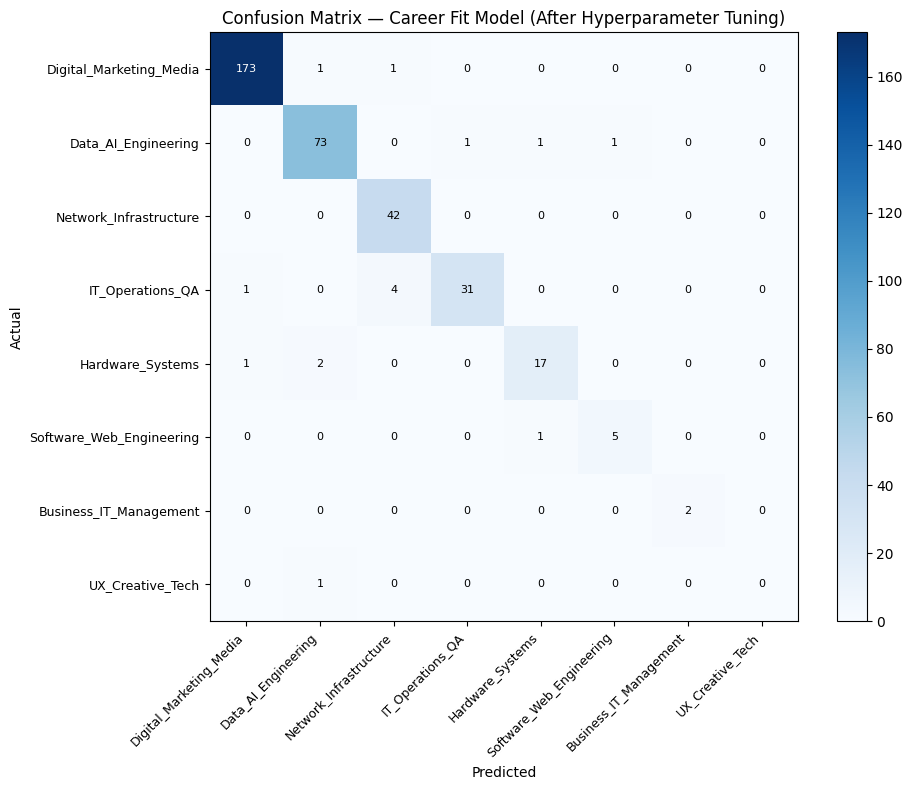


=== Per-Class Metrics (PySpark) ===
  accuracy                 : 0.9581
  f1                       : 0.9565
  weightedPrecision        : 0.9563
  weightedRecall           : 0.9581

=== Per-Label Precision & Recall ===
  Digital_Marketing_Media        Prec=0.989  Rec=0.989  F1=0.989
  Data_AI_Engineering            Prec=0.948  Rec=0.961  F1=0.954
  Network_Infrastructure         Prec=0.894  Rec=1.000  F1=0.944
  IT_Operations_QA               Prec=0.969  Rec=0.861  F1=0.912
  Hardware_Systems               Prec=0.895  Rec=0.850  F1=0.872
  Software_Web_Engineering       Prec=0.833  Rec=0.833  F1=0.833
  Business_IT_Management         Prec=1.000  Rec=1.000  F1=1.000
  UX_Creative_Tech               Prec=0.000  Rec=0.000  F1=0.000


In [9]:
# ─── CELL 9: Confusion Matrix + Per-Class Report (PySpark Only) ───
import matplotlib.pyplot as plt

# Collect predictions (only 2000 rows — safe for driver)
preds_pd = tuned_preds.select("label", "prediction").toPandas()

# Get label names from StringIndexerModel
label_model = cv_model.bestModel.stages[0]
labels = label_model.labels

# Build confusion matrix using PySpark groupBy
from pyspark.sql import functions as F

cm_spark = (tuned_preds
    .groupBy("label", "prediction")
    .count()
    .orderBy("label", "prediction"))

cm_spark.show(20, truncate=False)

# Convert to pivot for heatmap
n = len(labels)
cm_grid = [[0]*n for _ in range(n)]
for row in cm_spark.collect():
    r, c, cnt = int(row["label"]), int(row["prediction"]), int(row["count"])
    if r < n and c < n:
        cm_grid[r][c] = cnt

# Plot heatmap using only matplotlib (no seaborn needed)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_grid, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(labels, fontsize=9)
for r in range(n):
    for c in range(n):
        ax.text(c, r, str(cm_grid[r][c]), ha="center", va="center",
                color="white" if cm_grid[r][c] > max(max(row) for row in cm_grid)/2 else "black",
                fontsize=8)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Career Fit Model (After Hyperparameter Tuning)")
plt.tight_layout(); plt.show()

# Per-class metrics using PySpark MulticlassClassificationEvaluator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

print("\n=== Per-Class Metrics (PySpark) ===")
for metric in ["accuracy", "f1", "weightedPrecision", "weightedRecall"]:
    ev = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName=metric)
    val = float(ev.evaluate(tuned_preds))
    print(f"  {metric:<25}: {val:.4f}")

# Per-label F1 using manual PySpark calculation
print("\n=== Per-Label Precision & Recall ===")
total_rows = tuned_preds.count()
for li, lname in enumerate(labels):
    tp = tuned_preds.filter((F.col("label")==li) & (F.col("prediction")==li)).count()
    fp = tuned_preds.filter((F.col("label")!=li) & (F.col("prediction")==li)).count()
    fn = tuned_preds.filter((F.col("label")==li) & (F.col("prediction")!=li)).count()
    prec = tp/(tp+fp) if (tp+fp)>0 else 0.0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0.0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.0
    print(f"  {lname:<30} Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}")


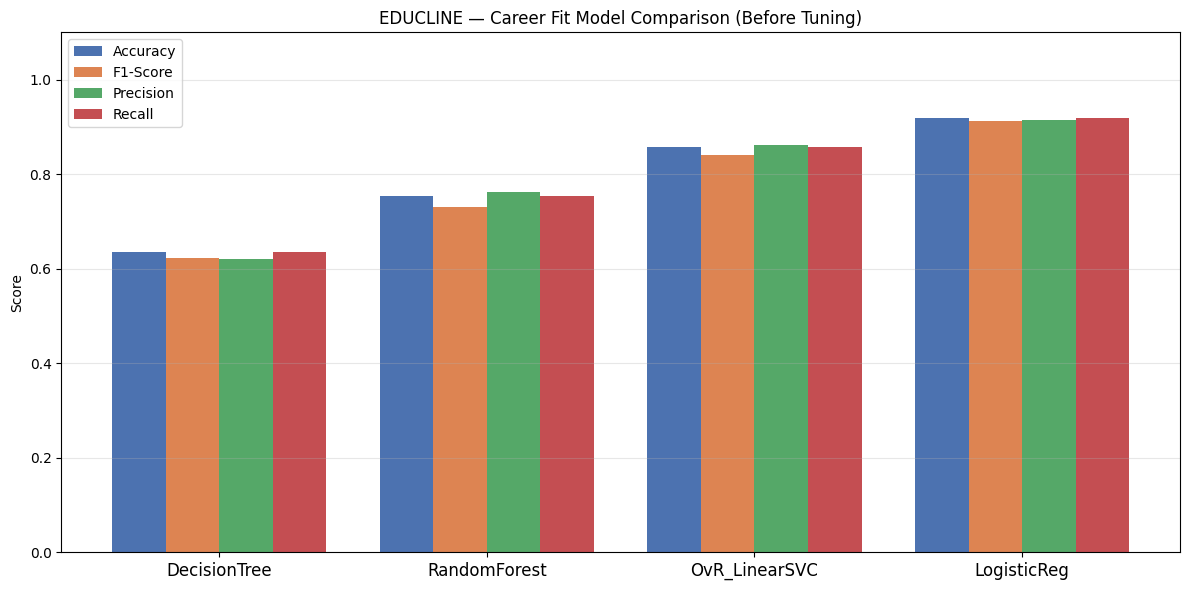


Final Tuned Model (LogisticReg): Accuracy=0.9581 | F1=0.9565


In [10]:
# ─── CELL 10: Algorithm Comparison Chart ───
import matplotlib.pyplot as plt
import numpy as np

names  = list(results.keys())
accs   = [results[n]["accuracy"]   for n in names]
f1s    = [results[n]["f1"]         for n in names]
precs  = [results[n]["precision"]  for n in names]
recs   = [results[n]["recall"]     for n in names]

x = np.arange(len(names))
w = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 1.5*w, accs,  w, label="Accuracy",  color="#4C72B0")
ax.bar(x - 0.5*w, f1s,   w, label="F1-Score",  color="#DD8452")
ax.bar(x + 0.5*w, precs, w, label="Precision", color="#55A868")
ax.bar(x + 1.5*w, recs,  w, label="Recall",    color="#C44E52")

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("EDUCLINE — Career Fit Model Comparison (Before Tuning)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFinal Tuned Model ({best_name}): Accuracy={tuned_acc:.4f} | F1={tuned_f1:.4f}")


In [11]:
# ─── CELL 11: Save Best Tuned Model ───
import os, shutil

os.makedirs(MODEL_OUT.rsplit("/", 1)[0], exist_ok=True)
cv_model.bestModel.write().overwrite().save(MODEL_OUT)
print("Best model saved:", MODEL_OUT)


Best model saved: /content/drive/MyDrive/FYP1/Model/career_fit_best_model


In [12]:
# ─── CELL 12: Generate Career Report (Top1/Top2/Top3 + 10 Roles) ───
from pyspark.sql.types import ArrayType, StringType
from pyspark.sql.window import Window
from pyspark.ml.pipeline import PipelineModel
from pyspark.ml.functions import vector_to_array

CLUSTER_ROLES = {
    "Software_Web_Engineering":  ["Software Developer","Software Engineer","Computer Programmer",
                                   "Web Developer","Programmer Analyst","Applications Programmer",
                                   "Systems Programmer","Webmaster","Computer Games Developer"],
    "Data_AI_Engineering":       ["Data Scientist","ML Engineer","Data Engineer","AI Developer",
                                   "Database Administrator","Database Designer","Computer Database Assistant"],
    "Network_Infrastructure":    ["Network Engineer","Network Administrator","Systems Administrator",
                                   "IT Infrastructure Engineer","Infrastructure (IT) Architect",
                                   "Telecommunications Engineer","Network Architect","Network Manager"],
    "IT_Operations_QA":          ["IT Quality Assurance Specialist","IT Auditor","Software Tester",
                                   "QA Engineer","IT Support Engineer","IT Operations Analyst",
                                   "Site Reliability Associate","Helpdesk Analyst","Systems Support Officer"],
    "UX_Creative_Tech":          ["UI/UX Designer","Product Designer","Graphic Designer",
                                   "Creative Technologist","Interaction Designer","Motion Designer",
                                   "Front-End Designer","Multimedia Designer","UX Researcher"],
    "Business_IT_Management":    ["Business Analyst","IT Project Manager","Product Manager",
                                   "IT Manager","Scrum Master","IT Consultant",
                                   "Business Systems Analyst","Operations Manager","Strategy Associate"],
    "Digital_Marketing_Media":   ["Digital Marketer","SEO Specialist","Content Strategist",
                                   "Social Media Manager","Growth Marketer","Brand Executive",
                                   "Marketing Analyst","Media Planner","Campaign Manager"],
    "Hardware_Systems":          ["Embedded Systems Engineer","Hardware Engineer","IoT Engineer",
                                   "Systems Engineer","Field Engineer","Electronics Engineer",
                                   "Mechatronics Associate","Device Technician","Lab Engineer"],
}

def build_10_roles(top1, top2, top3):
    def pick(c, n): return CLUSTER_ROLES.get(c, [])[:n]
    roles = pick(top1, 5) + pick(top2, 3) + pick(top3, 2)
    seen, out = set(), []
    for r in roles:
        if r and r not in seen:
            seen.add(r); out.append(r)
    for c in [top1, top2, top3]:
        for r in CLUSTER_ROLES.get(c, []):
            if len(out) >= 10: break
            if r not in seen: seen.add(r); out.append(r)
    return out[:10]

best_model_loaded = PipelineModel.load(MODEL_OUT)
df_all = spark.read.parquet(LABELED_PATH)
pred_all = best_model_loaded.transform(df_all)
pred_all = pred_all.withColumn("prob_arr", vector_to_array(F.col("probability")))

label_model_loaded = best_model_loaded.stages[0]
labels = label_model_loaded.labels
labels_array = F.array(*[F.lit(x) for x in labels])

pred_all = (pred_all
    .withColumn("label_arr", labels_array)
    .withColumn("pairs", F.arrays_zip("label_arr", "prob_arr")))

exploded = (pred_all
    .select("student_id", F.explode("pairs").alias("p"))
    .select("student_id",
            F.col("p.label_arr").alias("cluster"),
            F.col("p.prob_arr").alias("prob")))

w = Window.partitionBy("student_id").orderBy(F.desc("prob"))
top3 = exploded.withColumn("rn", F.row_number().over(w)).where(F.col("rn") <= 3)

top3_pivot = (top3.groupBy("student_id").pivot("rn", [1, 2, 3]).agg(F.first("cluster"))
              .withColumnRenamed("1", "Top1")
              .withColumnRenamed("2", "Top2")
              .withColumnRenamed("3", "Top3"))

@F.udf(returnType=ArrayType(StringType()))
def roles10_udf(t1, t2, t3):
    return build_10_roles(t1, t2, t3)

final_df = top3_pivot.withColumn("roles10", roles10_udf("Top1", "Top2", "Top3"))
for i in range(10):
    final_df = final_df.withColumn(f"role_{i+1}", F.col("roles10")[i])
final_df = final_df.drop("roles10")

# Save
os.makedirs(REPORT_OUT_DIR, exist_ok=True)
(final_df.coalesce(1).write.mode("overwrite").option("header", True).csv(REPORT_OUT_DIR))

import glob
part = glob.glob(REPORT_OUT_DIR + "/part-*.csv")
if part:
    shutil.copy(part[0], FINAL_CSV)
    print("Career fit report saved:", FINAL_CSV)

final_df.show(5, truncate=False)
print(f"Total students in report: {final_df.count()}")


Career fit report saved: /content/drive/MyDrive/FYP1/Dataset/career_fit_report.csv
+----------+-----------------------+-----------------------+-----------------------+-------------------------------+---------------------+---------------------+--------------------------+-----------------------------+----------------+---------------------+---------------------+-------------------------------+------------------+
|student_id|Top1                   |Top2                   |Top3                   |role_1                         |role_2               |role_3               |role_4                    |role_5                       |role_6          |role_7               |role_8               |role_9                         |role_10           |
+----------+-----------------------+-----------------------+-----------------------+-------------------------------+---------------------+---------------------+--------------------------+-----------------------------+----------------+---------------------+-